In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, roc_auc_score,
    f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)


In [2]:
df = pd.read_csv('data/creditcard_fraud.csv')
print('Dataset Shape:', df.shape)
print('\nClass Counts:')
print(df['Class'].value_counts())
print('\nFraud Percentage: {:.4f}%'.format(df['Class'].mean() * 100))


Dataset Shape: (284807, 30)

Class Counts:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage: 0.1727%


In [5]:
df['Amount_scaled'] = RobustScaler().fit_transform(df[['Amount']])

if 'Time' in df.columns:
    df['Time_scaled'] = RobustScaler().fit_transform(df[['Time']])
    X = df.drop(columns=['Time', 'Amount', 'Class'])
else:
    X = df.drop(columns=['Amount', 'Class'])

y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Train Shape:', X_train.shape, '| Train Fraud Ratio: {:.4f}%'.format(y_train.mean() * 100))
print('Test Shape: ', X_test.shape,  '| Test Fraud Ratio:  {:.4f}%'.format(y_test.mean() * 100))


Train Shape: (227845, 29) | Train Fraud Ratio: 0.1729%
Test Shape:  (56962, 29) | Test Fraud Ratio:  0.1720%


In [6]:
contamination = y_train.mean()
iso_forest = IsolationForest(contamination=contamination, random_state=42, n_jobs=-1)
iso_forest.fit(X_train)

iso_preds_raw = iso_forest.predict(X_test)
iso_preds = np.where(iso_preds_raw == -1, 1, 0)
iso_scores = -iso_forest.score_samples(X_test)

print('=== UNSUPERVISED ISOLATION FOREST ===')
print('PR-AUC (Average Precision): {:.4f}'.format(average_precision_score(y_test, iso_scores)))
print('ROC-AUC:                    {:.4f}'.format(roc_auc_score(y_test, iso_scores)))
print('F1-Score:                   {:.4f}'.format(f1_score(y_test, iso_preds)))
print('Precision:                  {:.4f}'.format(precision_score(y_test, iso_preds)))
print('Recall:                     {:.4f}'.format(recall_score(y_test, iso_preds)))


=== UNSUPERVISED ISOLATION FOREST ===
PR-AUC (Average Precision): 0.1714
ROC-AUC:                    0.9528
F1-Score:                   0.3232
Precision:                  0.3200
Recall:                     0.3265


In [9]:
scale_ratio = (len(y_train) - sum(y_train)) / sum(y_train)

models = {
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(scale_pos_weight=scale_ratio, random_state=42, verbose=-1, n_jobs=-1),
    'CatBoost': CatBoostClassifier(auto_class_weights='Balanced', verbose=0, random_state=42),
    'XGBoost (GPU)': XGBClassifier(scale_pos_weight=scale_ratio, device='cuda', tree_method='hist', eval_metric='logloss', random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_probs = model.predict_proba(X_test)[:, 1]
    y_preds = (y_probs >= 0.50).astype(int)
    
    pr_auc = average_precision_score(y_test, y_probs)
    roc_auc = roc_auc_score(y_test, y_probs)
    f1 = f1_score(y_test, y_preds)
    prec = precision_score(y_test, y_preds)
    rec = recall_score(y_test, y_preds)
    
    results.append({
        'Model': name,
        'PR-AUC (Primary)': pr_auc,
        'ROC-AUC': roc_auc,
        'F1-Score': f1,
        'Precision': prec,
        'Recall': rec
    })
    print(f"PR-AUC: {pr_auc:.4f} | ROC-AUC: {roc_auc:.4f} | F1: {f1:.4f}")


df_leaderboard = pd.DataFrame(results).sort_values(by='PR-AUC (Primary)', ascending=False).reset_index(drop=True)
print('\n' + '='*75)
print('DAY 9 EXTREME FRAUD DETECTION LEADERBOARD')
print('='*75)
print(df_leaderboard.to_string(index=False))


PR-AUC: 0.8440 | ROC-AUC: 0.9839 | F1: 0.7606
PR-AUC: 0.0234 | ROC-AUC: 0.9416 | F1: 0.0478
PR-AUC: 0.8749 | ROC-AUC: 0.9787 | F1: 0.7963
PR-AUC: 0.8705 | ROC-AUC: 0.9662 | F1: 0.8586

DAY 9 EXTREME FRAUD DETECTION LEADERBOARD
        Model  PR-AUC (Primary)  ROC-AUC  F1-Score  Precision   Recall
     CatBoost          0.874897 0.978712  0.796296   0.728814 0.877551
XGBoost (GPU)          0.870499 0.966193  0.858639   0.881720 0.836735
Random Forest          0.844035 0.983853  0.760563   0.704348 0.826531
     LightGBM          0.023359 0.941648  0.047767   0.024507 0.938776


OPTIMAL PRECISION-RECALL THRESHOLD: t* = 0.9620
At t* = 0.9620:
  Max F1-Score: 0.8729
  Precision:    0.9518
  Recall:       0.8061


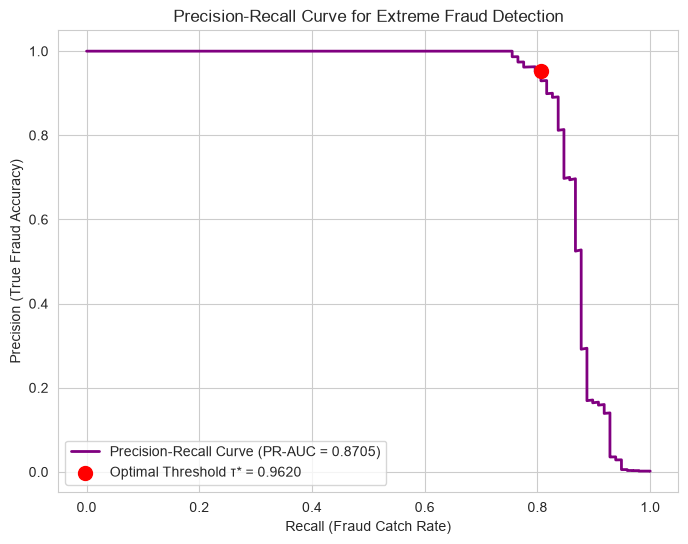

In [10]:
best_model = models['XGBoost (GPU)'] if 'XGBoost (GPU)' in models else models['CatBoost']
y_probs_best = best_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_best)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print('='*50)
print('OPTIMAL PRECISION-RECALL THRESHOLD: t* = {:.4f}'.format(optimal_threshold))
print('At t* = {:.4f}:'.format(optimal_threshold))
print('  Max F1-Score: {:.4f}'.format(f1_scores[best_idx]))
print('  Precision:    {:.4f}'.format(precisions[best_idx]))
print('  Recall:       {:.4f}'.format(recalls[best_idx]))
print('='*50)

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label='Precision-Recall Curve (PR-AUC = {:.4f})'.format(average_precision_score(y_test, y_probs_best)), color='purple', lw=2)
plt.scatter(recalls[best_idx], precisions[best_idx], color='red', s=100, label='Optimal Threshold τ* = {:.4f}'.format(optimal_threshold), zorder=5)
plt.xlabel('Recall (Fraud Catch Rate)')
plt.ylabel('Precision (True Fraud Accuracy)')
plt.title('Precision-Recall Curve for Extreme Fraud Detection')
plt.legend()
plt.show()


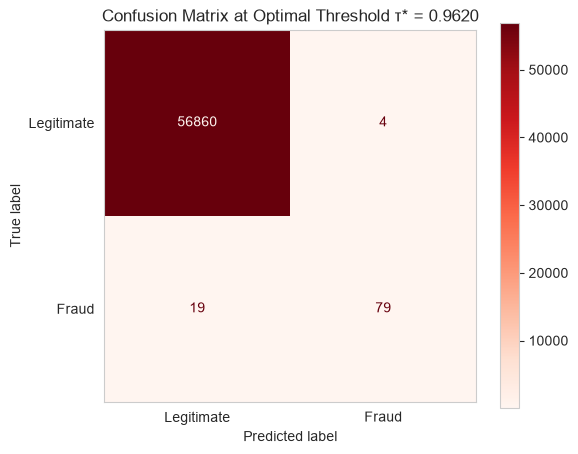

In [11]:
final_preds = (y_probs_best >= optimal_threshold).astype(int)

cm = confusion_matrix(y_test, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Reds', ax=ax)
plt.title('Confusion Matrix at Optimal Threshold τ* = {:.4f}'.format(optimal_threshold))
plt.grid(False)
plt.show()
